In [1]:
%pip install -q pennylane qiskit qiskit-aer matplotlib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 68.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 68.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import pennylane as qml
import qiskit

print("PennyLane:", qml.__version__)
print("Qiskit:   ", qiskit.__version__)

PennyLane: 0.45.0
Qiskit:    2.4.2


{np.str_('00'): np.int64(524), np.str_('11'): np.int64(476)}


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


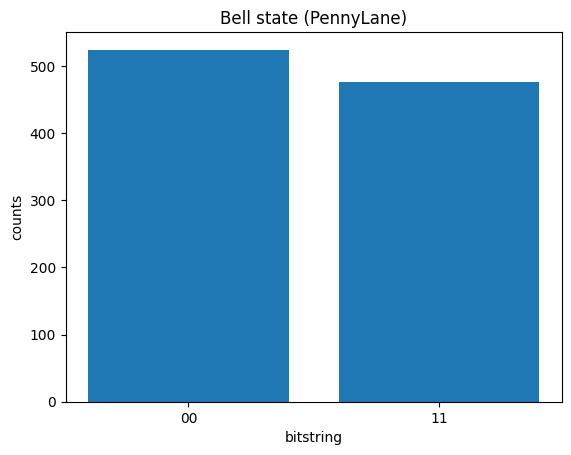

In [3]:
import matplotlib.pyplot as plt

dev = qml.device("default.qubit", wires=2, shots=1000)

@qml.qnode(dev)
def bell():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.counts()

counts = bell()
print(counts)

plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state (PennyLane)")
plt.show()

{'11': 484, '00': 516}


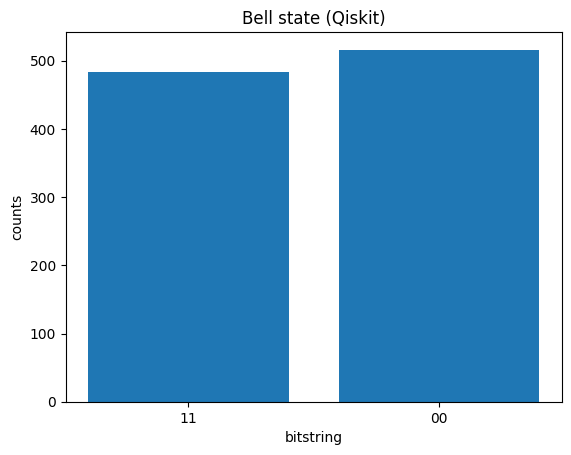

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()                      # a Sampler circuit must include measurements

result = Sampler().run([qc], shots=1000).result()
counts = result[0].data.meas.get_counts()
print(counts)

plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state (Qiskit)")
plt.show()

## Preparing the GHZ State

Its a good example of multipartite entanglement, where measurements on one particle instantaneously affect the others. For three qubits the Greenberger–Horne–Zeilinger state shows that you will either get the three particles in state |0> or state |1>. The roughly even distribution of |000> and |111> states indicates that the system is maximally entangled. Once you know whether the first qubit is a zero or one state, you know everything there is to know about the state.

{np.str_('000'): np.int64(515), np.str_('111'): np.int64(485)}


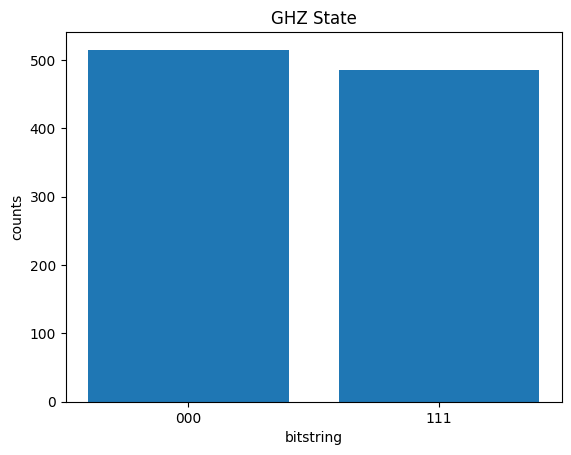

In [6]:
dev = qml.device("default.qubit", wires=3, shots=1000)

@qml.qnode(dev)
def ghz():
    qml.Hadamard(0)
    qml.CNOT([0,1])
    qml.CNOT([1,2])
    return qml.counts()

counts = ghz()
print(counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring") 
plt.ylabel("counts")
plt.title("GHZ State")
plt.show()


## Deutsch Joza

you are given a black-box function f that takes an n-bit binary string as an input and returns a single bit (either 0 or 1). 
The deutsch jozsa algorithm determines whether the function is either constant or balanced. 

If the function is constant, the phases match and the final Hadamard gates act like an inverse operation, gathering all the quantum amplitudes back into the starting state |000>. If the function is balanced, exactly half of the states have a flipped phase. This actuually creates perfect destructive interference at the |000> state which causes its probability to be zero and the amplitude goes to any other bitstring. 
The result of all counts in the |111> state means that for the balanced oracle every single input qubit impacts the function's output. Every qubit dictates a phase flip, the final Hadamard gates flip every single qubit from a |0> to a |1>.

Constant Oracle
{np.str_('000'): np.int64(1000)}
Balanced oracle
{np.str_('111'): np.int64(1000)}


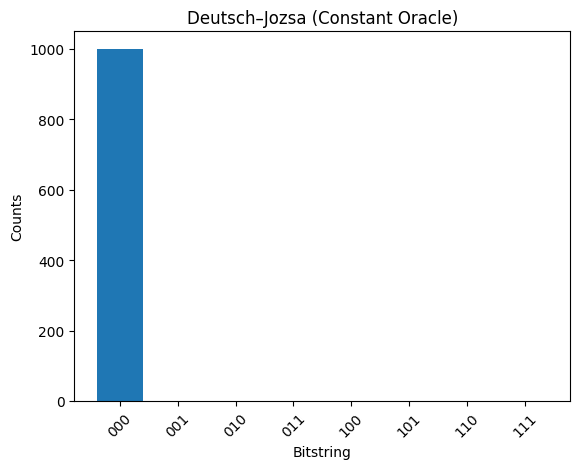

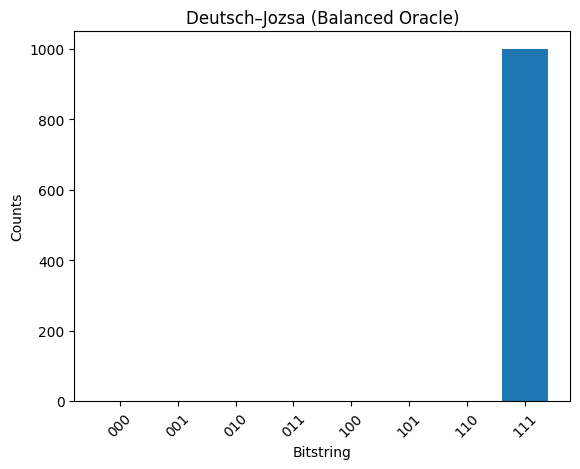

In [7]:


n = 3  # input qubits; wire n is the ancilla
dev = qml.device("default.qubit", wires=n + 1, shots=1000)

def oracle_constant():
    pass  # f(x) = 0 for all x  ->  do nothing

def oracle_balanced():
    for i in range(n):
        qml.CNOT(wires=[i,n])

@qml.qnode(dev)
def deutsch_jozsa(oracle):
    # ancilla -> |1>
    qml.PauliX(wires=n)

    # Hadamard all wires
    for i in range(n+1):
        qml.Hadamard(wires=i)

    oracle()

    # Hadamard the input wires
    for i in range(n):
        qml.Hadamard(wires=i)

    return qml.counts(wires=range(n))

print("Constant Oracle")
print(deutsch_jozsa(oracle_constant))
print("Balanced oracle")
print(deutsch_jozsa(oracle_balanced))

const_counts = deutsch_jozsa(oracle_constant)
bal_counts = deutsch_jozsa(oracle_balanced)

states = [format(i, f"0{n}b") for i in range(2**n)]

def plot_counts(counts, title):
    values = [counts.get(s, 0) for s in states]

    plt.bar(states, values)
    plt.title(title)
    plt.ylabel("Counts"); plt.xlabel("Bitstring")
    plt.xticks(rotation=45)
    plt.show()

plot_counts(const_counts, "Deutsch–Jozsa (Constant Oracle)")
plot_counts(bal_counts, "Deutsch–Jozsa (Balanced Oracle)")


## Grover Search 

The graphs for this algorithm show the shot distribution of finding each item in the search space, effectlively mavking a probability distribution.

After looking some things up I think that the reason the graph changes in the second and third iteration is because for a search space of 4 states the grover algorithm behaves like a wave. It rotates the quantum state vector towards its target, and when there are extra iterations performed it over roatates past the perfect peak.

{np.str_('11'): np.int64(1000)}
{np.str_('00'): np.int64(268), np.str_('01'): np.int64(235), np.str_('10'): np.int64(261), np.str_('11'): np.int64(236)}
{np.str_('00'): np.int64(257), np.str_('01'): np.int64(246), np.str_('10'): np.int64(254), np.str_('11'): np.int64(243)}
{np.str_('11'): np.int64(1000)}


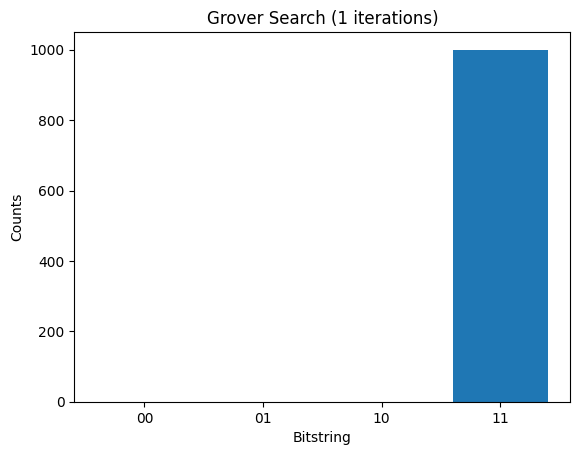

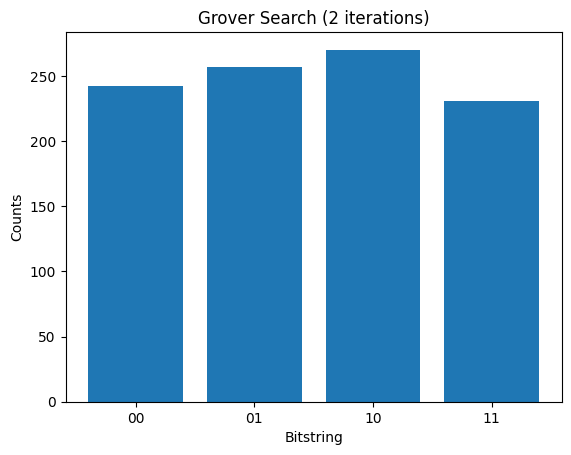

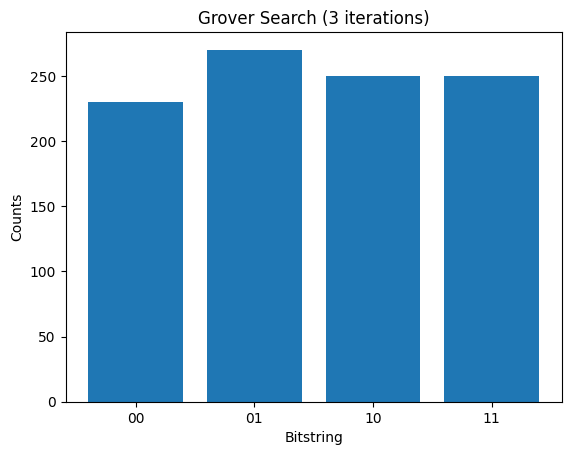

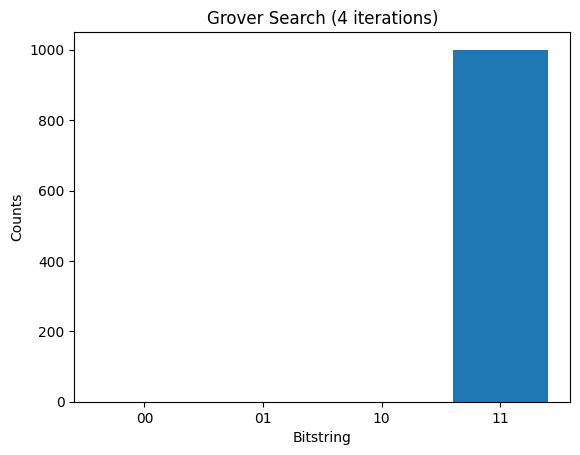

In [10]:
n = 2  # search space of size 2**n
dev = qml.device("default.qubit", wires=n, shots=1000)

@qml.qnode(dev)
def grover(num_iters=1):

    for i in range(n):
        qml.Hadamard(wires=i)

    for _ in range(num_iters):
        qml.FlipSign([1,1],wires=range(n))
        qml.GroverOperator(wires=range(n))

    return qml.counts()

results = {}

print(grover(num_iters=1))
print(grover(num_iters=2))
print(grover(num_iters=3))
print(grover(num_iters=4))


for k in [1, 2, 3, 4]:
    results[k] = grover(k)

def plot_counts(counts, title):
    states = ['00', '01', '10', '11']
    values = [counts.get(s, 0) for s in states]

    plt.bar(states, values)
    plt.title(title)
    plt.ylabel("Counts"); plt.xlabel("Bitstring")
    plt.show()

for k in [1, 2, 3,4]:
    plot_counts(results[k], f"Grover Search ({k} iterations)")

## QFT
The graph is showing the measurement probabilities after the QFT algorithm. So the basis state gets transformed into a superposition with complex phases and the graph shows the squared magnitudes of those amplitudes. Because measurement probabilities depend only on amplitude magnitudes and not phases, different Fourier-transformed states can produce similar-looking probability distributions.

The QFT algorithm I wrote does not match the built in one (although it is very similar), and this could be for a couple of reasons. The first could be that we are using a limited number of "shots" and the probabilities are estimated rather than being computed exactly in this case the difference is due to statistical noise. The other reason could be that I got the gate sequences or qubit ordering wrong although I tried changing around the order in which the hadamards and shifts are done and the algorithm just doesn't work. 


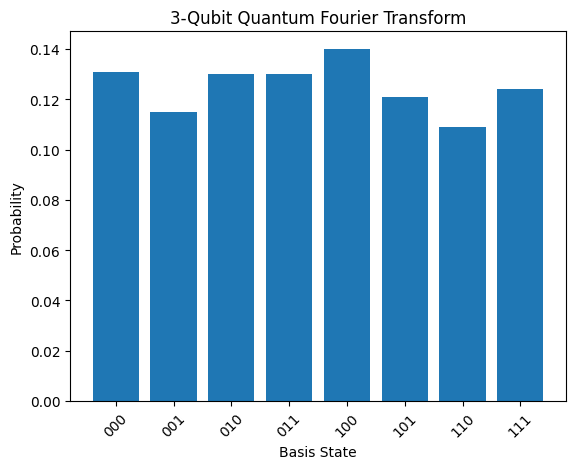

[0.118 0.119 0.133 0.116 0.133 0.123 0.124 0.134]
[0.133 0.123 0.141 0.132 0.119 0.129 0.094 0.129]
False


In [11]:
import numpy as np

n = 3
dev = qml.device("default.qubit", wires=n, shots=1000)

@qml.qnode(dev)
def qft_demo():

    # input state |101>
    qml.BasisState(np.array([1, 0, 1]), wires=range(n))

    # qubit 0
    qml.Hadamard(wires=0)
    qml.ControlledPhaseShift(np.pi/2, wires=[1, 0])
    qml.ControlledPhaseShift(np.pi/4, wires=[2, 0])

    # qubit 1
    qml.Hadamard(wires=1)
    qml.ControlledPhaseShift(np.pi/2, wires=[2, 1])

    # qubit 2
    qml.Hadamard(wires=2)

    # reverse qubit order
    qml.SWAP(wires=[0, 2])

    return qml.probs(wires=range(n))

probs = qft_demo()

labels = [format(i, f'0{n}b') for i in range(len(probs))]

plt.bar(labels, probs)
plt.title("3-Qubit Quantum Fourier Transform")
plt.ylabel("Probability")
plt.xlabel("Basis State")
plt.xticks(rotation=45)
plt.show()

@qml.qnode(dev)
def qft_builtin():

    qml.BasisState(np.array([1, 0, 1]), wires=range(n))

    qml.QFT(wires=range(n))

    return qml.probs(wires=range(n))


manual = qft_demo()
builtin = qft_builtin()
print(manual)
print(builtin)
print(np.allclose(manual, builtin))